# AI-Driven Bayesian Template for Hubbard's AIE in engineering decisions under uncertainty
### 2026/2027 Symposium Tutorial - Public Colab Shell

## Open in Google Colab

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/KirtisChristensen/AIE-Bayesian-Template-SEATN_Tutorial/blob/main/Publish/SE-ATN-2026/llm_bayesian_reliability_tool_symposium-tutorial-2026-Colab.ipynb)

This shell notebook installs private tutorial code from GitHub using a Colab secret token.

## Section 1 - Environment Setup

Before running code cells, choose one setup mode.

Colab mode (private GitHub install):
- TUTORIAL_LIB_TOKEN: GitHub token with access to the private tutorial repo
- OPENAI_API_KEY: OpenAI API key (optional if using offline fallback)

Local VS Code mode (pre-push testing):
- Preferred: set TUTORIAL_LIB_LOCAL_PATH to your local tutorial_lib folder
- Optional: set TUTORIAL_LIB_TOKEN in terminal env to test private git install flow locally

Then run cells top-to-bottom.

In [ ]:
# Install tutorial_lib from private GitHub token (Colab/private flow)
# or from local path (VS Code pre-push flow)
import os
import subprocess
import sys
from pathlib import Path


def _is_colab():
    try:
        import google.colab  # noqa: F401
        return True
    except Exception:
        return False


def _get_token():
    token = os.getenv('TUTORIAL_LIB_TOKEN', '').strip()
    if token:
        return token, 'environment variable TUTORIAL_LIB_TOKEN'

    if _is_colab():
        try:
            from google.colab import userdata
            token = (userdata.get('TUTORIAL_LIB_TOKEN') or '').strip()
            if token:
                return token, 'Colab secret TUTORIAL_LIB_TOKEN'
        except Exception:
            pass

    return '', 'none'


def _find_local_tutorial_lib():
    # 1) Explicit override
    explicit = os.getenv('TUTORIAL_LIB_LOCAL_PATH', '').strip()
    if explicit and Path(explicit, 'pyproject.toml').exists():
        return str(Path(explicit).resolve())

    # 2) Search upward for a sibling Publish/SE-ATN-2026/tutorial_lib
    here = Path.cwd().resolve()
    candidates = []
    for root in [here] + list(here.parents):
        p = root / 'Publish' / 'SE-ATN-2026' / 'tutorial_lib'
        if (p / 'pyproject.toml').exists():
            candidates.append(p)

    # 3) Workspace-specific fallback for current project layout
    project_hint = Path(
        r'c:\Users\Admin\Documents\AIE - Bayesian Template Generated from Problem Description\Publish\SE-ATN-2026\tutorial_lib'
    )
    if (project_hint / 'pyproject.toml').exists():
        candidates.append(project_hint)

    if candidates:
        return str(candidates[0].resolve())
    return ''


token, token_source = _get_token()
if token:
    pkg_url = (
        'git+https://' + token +
        '@github.com/KirtisChristensen/AIE---Bayesian-Template-Dev.git' +
        '@main#subdirectory=Publish/SE-ATN-2026/tutorial_lib'
    )
    print(f'Installing tutorial_lib from private GitHub using {token_source}...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg_url])
    print('tutorial_lib installed from private GitHub successfully.')
else:
    local_path = _find_local_tutorial_lib()
    if not local_path:
        raise ValueError(
            'No TUTORIAL_LIB_TOKEN found and local tutorial_lib path was not discovered. '
            'Set TUTORIAL_LIB_TOKEN or TUTORIAL_LIB_LOCAL_PATH, then re-run this cell.'
        )
    print(f'Installing tutorial_lib from local path: {local_path}')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', '-e', local_path])
    print('tutorial_lib installed from local path successfully.')

Installing tutorial_lib from local path: C:\Users\Admin\Documents\AIE - Bayesian Template Generated from Problem Description\Publish\SE-ATN-2026\tutorial_lib
tutorial_lib installed from local path successfully.


In [2]:
# Core imports
from tutorial_lib import *
import os
import json
import numpy as np
import pandas as pd
print('tutorial_lib imported')

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


tutorial_lib imported


### Configure LLM

If `OPENAI_API_KEY` exists in Colab secrets, this cell configures the client.
If not, use offline fallback in Section 4.

In [3]:
from openai import OpenAI

OPENAI_API_KEY = ''
try:
    from google.colab import userdata
    OPENAI_API_KEY = userdata.get('OPENAI_API_KEY') or ''
except Exception:
    OPENAI_API_KEY = os.getenv('OPENAI_API_KEY', '')

MODEL = 'gpt-4o-mini'
if OPENAI_API_KEY:
    client = OpenAI(api_key=OPENAI_API_KEY)
    set_llm(client, MODEL)
    print(f'LLM configured: {MODEL}')
else:
    print('No OPENAI_API_KEY detected; use offline fallback in Section 4.')

LLM configured: gpt-4o-mini


In [4]:
print('Setup checks:')

try:
    from importlib.metadata import version as _pkg_version
    _tl_version = _pkg_version('tutorial-lib')
except Exception:
    _tl_version = 'unknown'

print('  tutorial_lib version:', _tl_version)
print('  scenarios:', len(SCENARIO_LIBRARY))
print('  ready for Section 3 onward')

Setup checks:
  tutorial_lib version: 0.1.0
  scenarios: 4
  ready for Section 3 onward


---
## Section 3 - Step 1: Define Decision and Uncertainties

In [5]:
Section3_Step1_Interactive_Scenario_Config()

---
## Section 4 - Step 2: LLM Problem Parser to JSON

In [8]:
parsed_model_json = parse_problem_to_json(decision_frame['problem_description'])
print(json.dumps(parsed_model_json, indent=2))

# Keep tutorial_lib state and notebook variable aligned for validation/repair logs
BAYESIAN_MODEL_JSON.clear()
BAYESIAN_MODEL_JSON.update(parsed_model_json)
bayesian_model_json = BAYESIAN_MODEL_JSON

Section4_Step2_Validate_Parsed_Schema()
# If needed, uncomment:
# Section4_Step2_Use_Offline_Fallback()

{
  "schema_version": "1.0",
  "profile": "reliability",
  "problem_summary": "A centrifugal pump has experienced 3 failures in 24 months, and we need to decide on a preventive maintenance schedule versus run-to-failure maintenance.",
  "decision": "Determine whether to implement a 6-month preventive maintenance schedule or continue with run-to-failure maintenance for the next 12 months.",
  "measurement_nodes": [
    {
      "name": "failure_count",
      "description": "The number of failures experienced by the pump over a specified period.",
      "role": "observed_data",
      "distribution_family": "Poisson",
      "distribution_parameters": {
        "lambda": 0.125
      },
      "justification": "The Poisson distribution is appropriate for modeling the number of failures in a fixed period of time.",
      "data_source": "observed_data",
      "depends_on": []
    },
    {
      "name": "mtbf",
      "description": "Mean time between failures for the pump class based on historic

## ⚠ Schema Validation: PASS (after repair)

**5 repair(s) applied to LLM output** — LLM content preserved where valid; missing/invalid fields patched from the scenario template:

  - Node `failure_count`: renamed Poisson parameter `lambda` -> `mu`.

  - Node `mtbf`: renamed Uniform parameter `low` -> `lower`.

...

- **Schema version**: 1.0

- **Profile**: reliability

- **5** measurement nodes

- **Update chain**: mtbf → pm_effectiveness → failure_count

Validation passed. Ready to proceed to VoI and Bayesian inference.


---
## Section 5 - Step 3: Value of Information

── VoI Results ────────────────────────────────────────────────────
Posterior Gamma(alpha=58.864, beta=642.294) from offline template (built from decision_frame).
PM Effectiveness: Beta(4.78, 15.56) | mean η=23% | 90% CI [10%, 40%].
Horizon = 12 mo  |  PM cycle = 6 mo  |  N planned interventions = 2.
Best strategy under current uncertainty: Implement 6-month PM schedule
  E[cost | current uncertainty]:  $19,369
  E[cost | perfect information]:  $18,903
  EVPI:                           $466

Interpretation:
  → EVPI = $466. Moderate value in better data.
  → Low-cost options (sensor data, peer benchmarks, or a small PM pilot)
     are worth pursuing; a full monitoring program may not be.


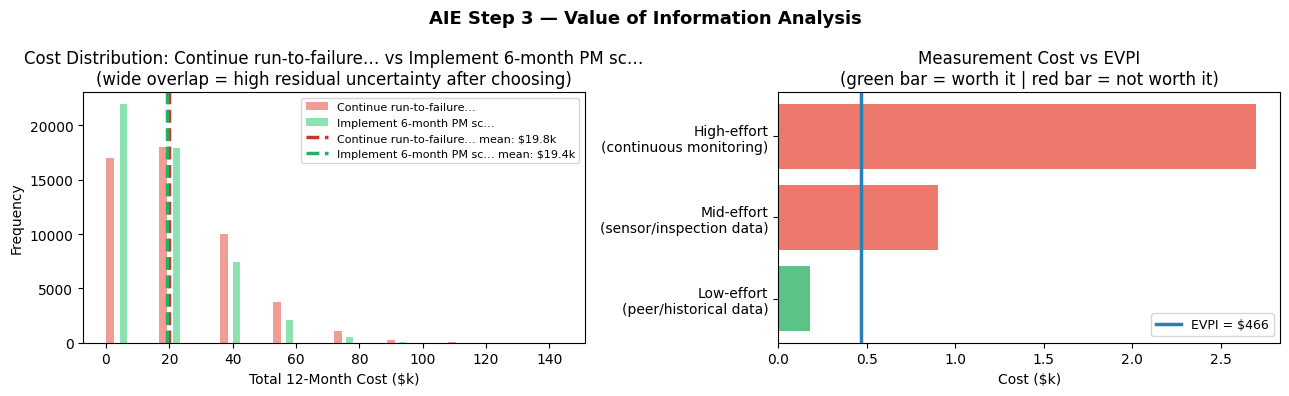

### How to Read This Section


| Quantity | Value | What it means |
|---|---|---|
| Best strategy (current data) | Implement 6-month PM schedule | The lower expected-cost option given what we know now |
| E\[cost \| uncertainty\] | $19,369 | Expected cost if we commit to the best known strategy |
| E\[cost \| perfect info\] | $18,903 | Expected cost if we always knew the true λ and PM effectiveness |
| **EVPI** | **$466** | **Maximum worth spending to reduce uncertainty in λ and PM effectiveness** |

**AIE Rule of Thumb**: only invest in more measurement if its cost < EVPI.  
Bars coloured green in the chart above are cost-justified; red bars are not.


In [9]:
Section5_Step3_Compute_VoI()
Section5_Step3_Plot_VoI()

---
## Section 6 - Step 4: Calibrated Priors

In [10]:
Section6_Step4_Expert_CI_Override()
Section6_Step4_Compute_Path_A()

PATH A — Expert Calibrated Prior:
  Source:               industry (no expert override applied)
  Expert MTBF 90% CI:   [9.0, 14.0] months
  Industry MTBF 90% CI: [9.0, 14.0] months
  Lambda 90% CI:        [0.0714, 0.1111] failures/month
  Fitted Gamma:         alpha=55.86, rate=618.29
  Prior mean lambda:    0.0904 → implied MTBF = 11.1 months


In [11]:
Section6_Step4_TTF_Data_Entry()
Section6_Step4_Compute_Path_B()

PATH B — Data-Fitted Prior:
  TTF source:           synthetic (10 draws from Exp(mean=11.5 mo), seed=42)
  Sample size:          10
  Sample mean TTF:      16.79 months

  -- Descriptive fits (failure-mechanism insight) --
  Exponential fit:  scale=16.79  | log-likelihood=-38.21
  Weibull fit:      shape k=1.12, scale=17.38 | log-likelihood=-38.13
  → Weibull provides better fit; Weibull shape k=1.12 → wear-out failures (increasing hazard — PM is beneficial)

  -- Data-derived Bayesian prior on lambda (for Section 7 inference) --
  Gamma(alpha=10.00, rate=167.95) via conjugate update from flat prior
  Prior mean lambda:    0.0595 → implied MTBF = 16.8 months


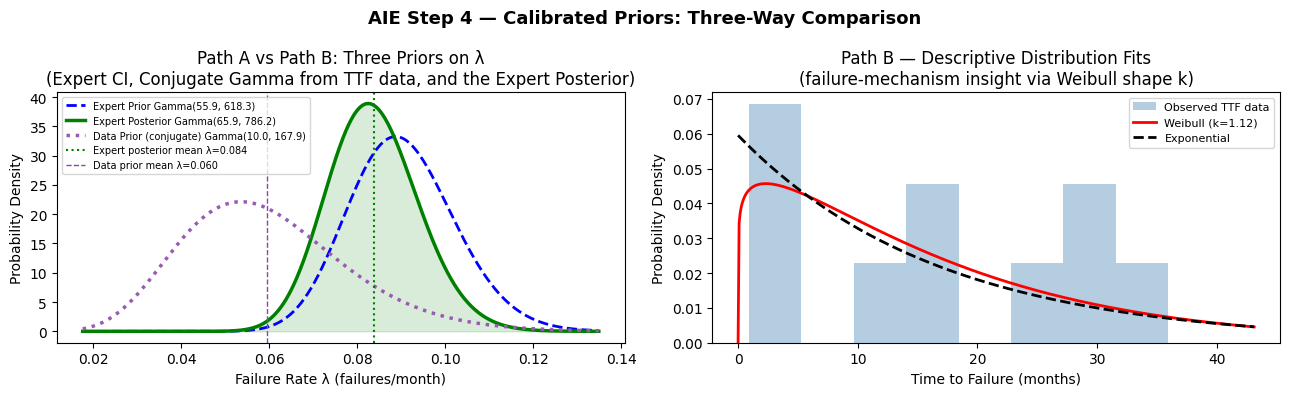

In [12]:
Section6_Step4_Plot_Prior_Comparison()

---
## Section 7 - Step 5: Posterior Sampling and Prior Sensitivity

In [13]:
Section7_Step5_Run_Hardcoded_Model()

── Hardcoded Model (Path A Prior) ───────────────────────────────────
  Prior       (Path A): Gamma(alpha=55.86, rate=618.29)
                        fitted to expert MTBF 90% CI [9.0, 14.0] months
                        prior mean λ = 0.0904 → implied MTBF = 11.1 mo
  New info    (likelihood): Path B TTF data (10 records, total exposure 167.9 mo)
                        Poisson(λ × 167.9 mo) conditioned on 10 observed failures
  Posterior:            updated Gamma on λ sampled via MCMC (NUTS)

Starting PyMC sampling...


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [lambda_rate]


Output()

[tuning] chain 1: 250/1000

[tuning] chain 1: 500/1000

...

[sampling] chain 1: 1000/2000

[sampling] chain 1: 1500/2000

[sampling] chain 1: 2000/2000

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 31 seconds.



Bayesian sampling complete — only lambda_rate sampled (NUTS, no CompoundStep).


In [14]:
Section7_Step5_Run_Dynamic_Model()

Dynamic builder inputs:
  source JSON:      BAYESIAN_MODEL_JSON
  prior node:       mtbf → Gamma(α=55.86, β=618.29) [from LLM Uniform MTBF(9,14) mo]
  likelihood data:  Path B TTF data (10 records, total exposure 167.9 mo)
  likelihood node:  failure_count → Poisson(mu=lambda_rate × 167.9)


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [lambda_rate]


Output()

Sampling 4 chains for 800 tune and 1_500 draw iterations (3_200 + 6_000 draws total) took 30 seconds.


In [15]:
Section7_Step5_Run_Data_Prior_Model()

Initializing NUTS using jitter+adapt_diag...


Data-prior model inputs:
  source prior:     Path B (Gamma(alpha=10.00, beta=167.95) from TTFs)
  prior mean λ:     0.0595 → implied MTBF = 16.8 months
  likelihood data:  Path B TTF data (10 records, total exposure 167.9 mo)
  likelihood:       Poisson(mu=lambda_rate * 167.9)


Multiprocess sampling (4 chains in 4 jobs)
NUTS: [lambda_rate]


Output()

Sampling 4 chains for 800 tune and 1_500 draw iterations (3_200 + 6_000 draws total) took 31 seconds.


Data-prior Gamma-Poisson sampling complete.


In [16]:
Section7_Step5_Run_Elicited_Model()

Initializing NUTS using jitter+adapt_diag...


Elicited-prior model inputs:
  source prior:     LLM (gpt-4o-mini) via parse_problem_to_bins()
  bin edges (mo):   [3.00, 4.66, 7.23, 11.22, 17.43, 27.05, 42.00]
  bin probs:        [0.050, 0.100, 0.400, 0.300, 0.100, 0.050]
  fit Gamma:        Gamma(alpha=4.74, beta=46.69)
  prior mean λ:     0.1016 → implied MTBF = 9.8 months
  likelihood data:  Path B TTF data (10 records, total exposure 167.9 mo)
  likelihood:       Poisson(mu=lambda_rate * 167.9)


Multiprocess sampling (4 chains in 4 jobs)
NUTS: [lambda_rate]


Output()

Sampling 4 chains for 800 tune and 1_500 draw iterations (3_200 + 6_000 draws total) took 32 seconds.


Elicited-prior Gamma-Poisson sampling complete.


### Four-Way Prior Sensitivity Analysis Results

,Prior source,Posterior mean λ,Implied MTBF (mo),90% HDI low,90% HDI high
Model,,,,,
Hardcoded (Expert 90% CI),Path A - calibrated from MTBF CI,0.084,11.9,0.066,0.100
Dynamic (LLM family-JSON parse),"Gamma(α=55.86, β=618.29) [from LLM Uniform MTB...",0.084,11.9,0.067,0.100
Data-prior (Path B TTFs),"Path B - Gamma(10.0, 167.9) from TTFs",0.059,16.9,0.038,0.081
Elicited (LLM binned quantiles),LLM (gpt-4o-mini) via parse_problem_to_bins() ...,0.069,14.5,0.038,0.097


Posterior mean spread (max-min): 0.0250 failures/month (33.8%)
  Expert    prior implied MTBF:  11.9 months
  LLM fam.  prior implied MTBF:  11.9 months
  Data      prior implied MTBF:  16.9 months
  Elicited  prior implied MTBF:  14.5 months



**Prior Sensitivity: HIGH**

> The priors produce substantially different posteriors and likely different decision recommendations. Prior choice is the dominant driver of the result - the data alone is insufficient to resolve the uncertainty. AIE action: this is a high-VoI situation. Better elicitation, additional TTF observations, or a pilot study is strongly warranted before deciding.

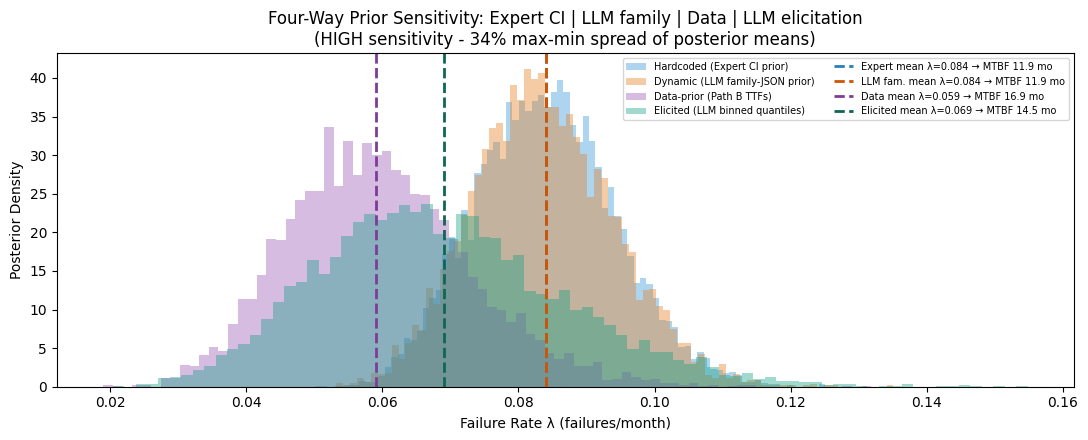

In [17]:
Section7_Step5_Compare_Four_Priors()

In [ ]:
Section7_Step5_Posterior_Summary_Hardcoded()

---
## Section 8 - Step 5b/5c: DAG Visualization

In [ ]:
Section8_Step5b_Plot_Bayesian_DAG()
Section8_Step5c_Plot_Bayesian_Update_Subgraph()

---
## Section 9 - Step 7: Monte Carlo Decision Recommendation

In [ ]:
Section9_Step7_Compute_Monte_Carlo()
Section9_Step7_Plot_Decision()